<a href="https://colab.research.google.com/github/toryor31oct/group15-Fun-Rai-Kwam-plod-Phai/blob/mail/Grap_Part_Mail_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# โหลดไฟล์ข้อมูลการเคลม

In [2]:
import pandas as pd

# (มีข้อมูลลูกค้าและกรมธรรม์อยู่แล้ว)
df_claims = pd.read_csv("claims_system_300.csv")

# ตั้งค่าฟอร์แมตตัวเลข
pd.options.display.float_format = "{:,.2f}".format


# กราฟBar จำนวนเคส + กราฟbar ยอดสูงสุด + กราฟbar ค่าเฉลี่ย


คำถามที่ 4: ผู้รับประโยชน์กลุ่มไหน (บิดา, มารดา, บุตร ฯลฯ) มีจำนวนเคสมากสุด พร้อมยอดจ่ายสูงสุดและค่าเฉลี่ย?

In [3]:
# คำถามที่ 4: ผู้รับประโยชน์กลุ่มไหน (บิดา, มารดา, บุตร ฯลฯ) มีจำนวนเคสมากสุด พร้อมยอดจ่ายสูงสุดและค่าเฉลี่ย?

q4_df = (df_claims.groupby("beneficiary_relationship").agg(
         total_cases = ("claim_id", "count"),
         max_net_payout = ("net_payout", "max"),
         avg_net_payout = ("net_payout", "mean"),).sort_values(by="total_cases", ascending=False))

display(q4_df)



,total_cases,max_net_payout,avg_net_payout
beneficiary_relationship,,,
บุตร,60,"2,722,500.00","866,835.03"
พี่น้อง,51,"2,920,500.00","967,573.84"
สามี,51,"2,871,000.00","719,399.80"
ภรรยา,51,"2,970,000.00","977,530.77"
บิดา,45,"2,920,500.00","948,092.90"
มารดา,42,"2,920,500.00","842,115.52"


#Bar จำนวนเคส

In [4]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

In [5]:
# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fonts-tlwg-purisa
  fonts-tlwg-purisa-ttf fonts-tlwg-sawasdee fonts-tlwg-sawasdee-ttf
  fonts-tlwg-typewriter fonts-tlwg-typewriter-ttf fonts-tlwg-typist
  fonts-tlwg-typist-ttf fonts-tlwg-typo fonts-tlwg-typo-ttf fonts-tlwg-umpush
  fonts-tlwg-umpush-ttf fonts-tlwg-waree fonts-tlwg-waree-ttf
The following NEW packages will be installed:
  fonts-thai-tlwg fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fo

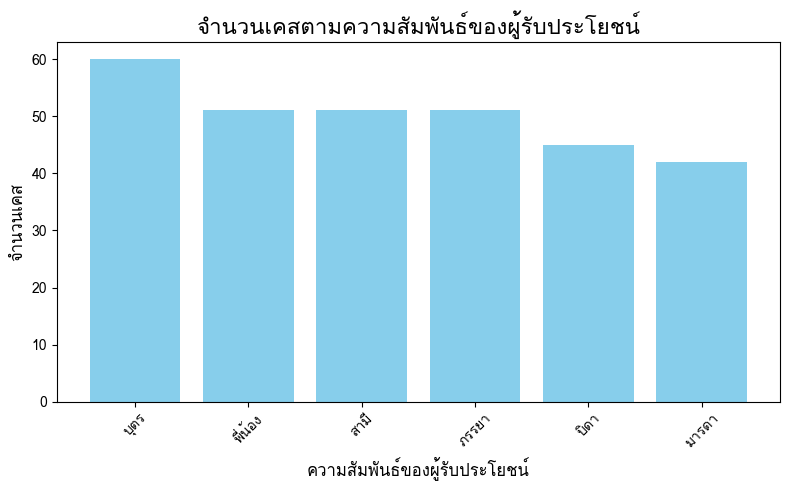

In [6]:
# กราฟแท่งที่ 1 : จำนวนเคสตามความสัมพันธ์ของผู้รับประโยชน์

q4_cases = (
    df_claims.groupby("beneficiary_relationship")
    .agg(total_cases=("claim_id", "count"))
    .sort_values(by="total_cases", ascending=False)
)

plt.figure(figsize=(8, 5))
plt.bar(q4_cases.index, q4_cases["total_cases"], color="skyblue")

plt.title("จำนวนเคสตามความสัมพันธ์ของผู้รับประโยชน์", fontsize=16)
plt.xlabel("ความสัมพันธ์ของผู้รับประโยชน์", fontsize=12)
plt.ylabel("จำนวนเคส", fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Bar ยอดสูงสุด

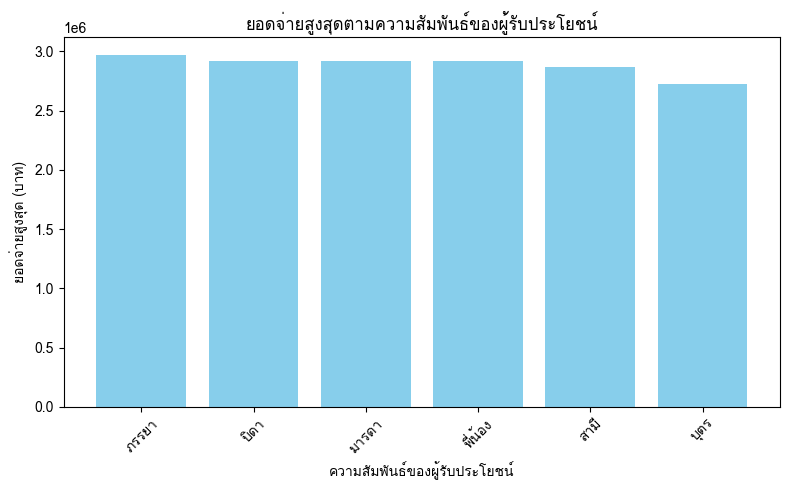

In [7]:
q4_max = (
    df_claims.groupby("beneficiary_relationship")
    .agg(max_payout=("net_payout", "max"))
    .sort_values("max_payout", ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    q4_max.index,
    q4_max["max_payout"],
    color="skyblue"
)

plt.title("ยอดจ่ายสูงสุดตามความสัมพันธ์ของผู้รับประโยชน์")
plt.xlabel("ความสัมพันธ์ของผู้รับประโยชน์")
plt.ylabel("ยอดจ่ายสูงสุด (บาท)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Bar ค่าเฉลี่ย

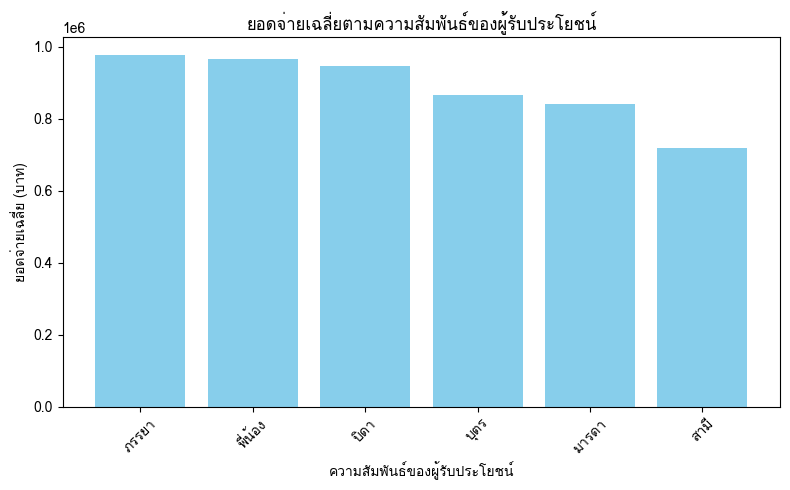

In [8]:
q4_avg = (
    df_claims.groupby("beneficiary_relationship")
    .agg(avg_payout=("net_payout", "mean"))
    .sort_values("avg_payout", ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    q4_avg.index,
    q4_avg["avg_payout"],
    color="skyblue"
)

plt.title("ยอดจ่ายเฉลี่ยตามความสัมพันธ์ของผู้รับประโยชน์")
plt.xlabel("ความสัมพันธ์ของผู้รับประโยชน์")
plt.ylabel("ยอดจ่ายเฉลี่ย (บาท)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()